# Preparation

In [50]:

# Credit Approval ML pipeline
import os
import urllib.request
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
# Full pipeline code goes here, see the canvas file. (Omitted for brevity in this snippet.)


In [51]:
# 1) Load dataset
uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data'
local_filename = 'crx.data'


if not os.path.exists(local_filename):
  try:
    print('Downloading dataset from UCI...')
    urllib.request.urlretrieve(uci_url, local_filename)
    print('Downloaded to', local_filename)
  except Exception as e:
    print('Could not download dataset automatically. Please download manually from:')
    print(uci_url)



# column names: A1..A15 and the last column is the class
col_names = [f'A{i}' for i in range(1, 16)] + ['class']


df = pd.read_csv(local_filename, header=None, names=col_names, na_values='?')

Downloaded to crx.data


## EDA

In [53]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  class   690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB
None
A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14 

In [ ]:
categorical_columns = []

for col in df.select_dtypes(include=['object']).columns:
    if(col != "class"):
        categorical_columns.append(col)

numerical_columns = []

for col in df.select_dtypes(include=['number']).columns:
    if(col != "class"):
        numerical_columns.append(col)


['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

In [79]:
df.sample(20)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
286,a,NaN,1.500,u,g,ff,ff,0.000,f,t,2,t,g,200.0,105,-
393,b,24.75,0.540,u,g,m,v,1.000,f,f,0,t,g,120.0,1,-
213,b,23.08,11.500,u,g,i,v,3.500,t,t,9,f,g,56.0,742,+
114,b,20.67,1.250,y,p,c,h,1.375,t,t,3,t,g,140.0,210,-
320,b,21.25,1.500,u,g,w,v,1.500,f,f,0,f,g,150.0,8,+
503,b,28.25,5.125,u,g,x,v,4.750,t,t,2,f,g,420.0,7,+
248,NaN,24.50,12.750,u,g,c,bb,4.750,t,t,2,f,g,73.0,444,+
12,a,38.25,6.000,u,g,k,v,1.000,t,f,0,t,g,0.0,0,+
473,b,19.17,4.000,y,p,i,v,1.000,f,f,0,t,g,360.0,1000,-
386,b,22.58,1.500,y,p,aa,v,0.540,f,f,0,t,g,120.0,67,-


In [83]:
a4_imputer = SimpleImputer(strategy="most_frequent")

df["A4"] = a4_imputer.fit_transform(df[["A4"]]).ravel()

In [85]:
df.head(623)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,b,29.58,4.750,u,g,m,v,2.000,f,t,1,t,g,460.0,68,-
619,b,18.42,10.415,y,p,aa,v,0.125,t,f,0,f,g,120.0,375,-
620,b,22.17,2.250,u,g,i,v,0.125,f,f,0,f,g,160.0,10,-
621,b,22.67,0.165,u,g,c,j,2.250,f,f,0,t,s,0.0,0,+


In [86]:
a14_imputer = SimpleImputer(strategy="mean")

df["A14"] = a14_imputer.fit_transform(df[["A14"]]).ravel()

In [87]:
df.head(623)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.000000,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.000000,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.000000,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.000000,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.000000,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,b,29.58,4.750,u,g,m,v,2.000,f,t,1,t,g,460.000000,68,-
619,b,18.42,10.415,y,p,aa,v,0.125,t,f,0,f,g,120.000000,375,-
620,b,22.17,2.250,u,g,i,v,0.125,f,f,0,f,g,160.000000,10,-
621,b,22.67,0.165,u,g,c,j,2.250,f,f,0,t,s,0.000000,0,+


In [88]:
df.isnull().sum()

A1       12
A2       12
A3        0
A4        0
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14       0
A15       0
class     0
dtype: int64

In [89]:
for col in df.select_dtypes(include='object').columns:
    imputer = SimpleImputer(strategy="most_frequent")
    df[col] = imputer.fit_transform(df[[col]]).ravel()

for col in df.select_dtypes(include='number').columns:
    imputer = SimpleImputer(strategy="mean")
    df[col] = imputer.fit_transform(df[[col]]).ravel()

In [90]:
df.isnull().sum()

A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
A15      0
class    0
dtype: int64

In [91]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [92]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1.0,0,0,202.0,0.0,0
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6.0,0,0,43.0,560.0,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0.0,0,0,280.0,824.0,0
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5.0,1,0,100.0,3.0,0
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0.0,0,2,120.0,0.0,0


In [94]:
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

class_mapping

{'+': np.int64(0), '-': np.int64(1)}

In [95]:
numeric_features = [col for col in numerical_columns]

print("Numeric features used for outlier removal:", numeric_features)

Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = ~((df[numeric_features] < lower) | (df[numeric_features] > upper)).any(axis=1)

print("Rows before outlier removal:", df.shape[0])
df_no_out = df[mask].copy()
print("Rows after outlier removal:", df_no_out.shape[0], "(removed", df.shape[0] - df_no_out.shape[0], "rows)")

df = df_no_out

Numeric features used for outlier removal: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Rows before outlier removal: 690
Rows after outlier removal: 473 (removed 217 rows)


In [96]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

             A1        A2        A3  ...       A14       A15     class
A1     1.000000  0.048331 -0.069205  ...  0.106807 -0.075290  0.030391
A2     0.048331  1.000000 -0.076948  ...  0.117832 -0.005973 -0.034631
A3    -0.069205 -0.076948  1.000000  ... -0.180708  0.039886 -0.152456
A4     0.045171 -0.060886 -0.024387  ... -0.037924 -0.078776  0.176275
A5     0.045171 -0.060886 -0.024387  ... -0.037924 -0.078776  0.176275
A6    -0.047978  0.059386  0.023072  ...  0.120286  0.030812 -0.126197
A7     0.082334 -0.149197 -0.039459  ... -0.069273 -0.048804 -0.003786
A8     0.060354  0.202704  0.177125  ...  0.134346  0.093505 -0.312195
A9    -0.047793  0.049321  0.211055  ...  0.006699  0.207791 -0.673597
A10   -0.108461 -0.118437  0.085481  ... -0.032586  0.291995 -0.343816
A11   -0.082858 -0.021675  0.115490  ... -0.028219  0.316665 -0.390429
A12    0.032296  0.091469  0.010584  ...  0.133865 -0.081183 -0.001446
A13    0.112895  0.025349 -0.107181  ...  0.049180 -0.173066  0.042882
A14   

In [97]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,1,30.83,0.000,1,0,12,7,1.25,1,1,1.0,0,0,202.0,0.0,0
1,0,58.67,4.460,1,0,10,3,3.04,1,1,6.0,0,0,43.0,560.0,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0.0,0,0,280.0,824.0,0
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5.0,1,0,100.0,3.0,0
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0.0,0,2,120.0,0.0,0


In [106]:
corr = df.corrwith(df['A1'], numeric_only = True)
print(corr)

corr2 = df['A1'].corr(df['A2'])
print(corr2)

A1       1.000000
A2       0.048331
A3      -0.069205
A4       0.045171
A5       0.045171
A6      -0.047978
A7       0.082334
A8       0.060354
A9      -0.047793
A10     -0.108461
A11     -0.082858
A12      0.032296
A13      0.112895
A14      0.106807
A15     -0.075290
class    0.030391
dtype: float64
0.04833120464826381


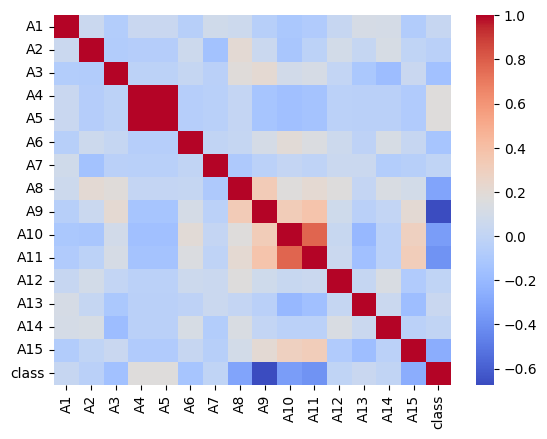

In [110]:
import seaborn as sns

sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [ ]:
corr_with_target = corr_matrix['class'].abs().sort_values(ascending=False)

threshold = 0.05

selected_features = corr_with_target[corr_with_target > threshold].index.tolist()

selected_features = [col for col in selected_features if col != 'class']


SyntaxError: invalid syntax (2343393141.py, line 7)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split()